## Import libraries

In [ ]:
import os
import time
import numpy as np
import tensorflow as tf
import kagglehub
import matplotlib.pyplot as plt
from datasets import load_from_disk
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report

## Load and prepare data

In [ ]:
# ==========================================
# STEP 1: LOAD AND PREPARE DATA
# ==========================================

# Download latest version
path = kagglehub.dataset_download("phantrntngvyk64cntt/processed-rsitmd-256-clean")

print("Path to dataset files:", path)
hf_dataset = load_from_disk(path)

# Extract class information safely
try:
    class_names = hf_dataset['train'].features['label'].names
except AttributeError:
    unique_labels = hf_dataset['train'].unique('label')
    class_names = [str(label) for label in sorted(unique_labels)]

num_classes = len(class_names)
print(f"Found {num_classes} classes: {class_names}")

# Create Label Encoder
#label_encoder = tf.keras.layers.StringLookup(vocabulary=class_names, num_oov_indices=0)

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

def preprocess_for_tf(image, label):
    # Resize and format the image for ResNet50
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    # Bypass the string lookup and just ensure it is a standard integer
    label = tf.cast(label, tf.int32)

    return image, label

print("Converting to TensorFlow datasets...")
train_dataset = hf_dataset["train"].to_tf_dataset(
    columns=["image"], label_cols=["label"], batch_size=BATCH_SIZE, shuffle=False
)
train_dataset = train_dataset.map(preprocess_for_tf, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

validation_dataset = hf_dataset["validation"].to_tf_dataset(
    columns=["image"], label_cols=["label"], batch_size=BATCH_SIZE, shuffle=False
)
validation_dataset = validation_dataset.map(preprocess_for_tf, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

Using Colab cache for faster access to the 'processed-rsitmd-256-clean' dataset.
Path to dataset files: /kaggle/input/processed-rsitmd-256-clean
Found 33 classes: ['airport', 'bareland', 'baseballfield', 'beach', 'boat', 'bridge', 'center', 'church', 'commercial', 'denseresidential', 'desert', 'farmland', 'forest', 'industrial', 'intersection', 'meadow', 'mediumresidential', 'mountain', 'park', 'parking', 'plane', 'playground', 'pond', 'port', 'railwaystation', 'resort', 'river', 'school', 'sparseresidential', 'square', 'stadium', 'storagetanks', 'viaduct']
Converting to TensorFlow datasets...


## Build ResNet50 Feature Extractor

In [ ]:
# ==========================================
# STEP 2: BUILD RESNET50 FEATURE EXTRACTOR
# ==========================================
print("Building ResNet50 Feature Extractor...")
base_model = tf.keras.applications.ResNet50(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.resnet50.preprocess_input(inputs)
x = base_model(x, training=False)
outputs = tf.keras.layers.GlobalAveragePooling2D()(x)

# Note: We stop at the pooling layer. There is NO Dense layer here!
feature_extractor = tf.keras.Model(inputs, outputs)

Building ResNet50 Feature Extractor...


## Extract features to Memory

In [ ]:
# ==========================================
# STEP 3: EXTRACT FEATURES TO MEMORY
# ==========================================
# Scikit-Learn SVMs require data in memory as NumPy arrays (X_train, y_train)
def extract_features_and_labels(dataset, name="Dataset"):
    print(f"Extracting features from {name}...")
    features_list = []
    labels_list = []

    for images, labels in dataset:
        # Pass images through ResNet50 to get a 2048-number array per image
        features = feature_extractor.predict(images, verbose=0)
        features_list.append(features)
        labels_list.extend(labels.numpy())

    # Stack the lists into a single large NumPy matrix
    X = np.vstack(features_list)
    y = np.array(labels_list)
    return X, y

X_train, y_train = extract_features_and_labels(train_dataset, "Training Set")
X_val, y_val = extract_features_and_labels(validation_dataset, "Validation Set")

print(f"Extracted Training Shape: {X_train.shape}")
print(f"Extracted Validation Shape: {X_val.shape}")

Extracting features from Training Set...
Extracting features from Validation Set...
Extracted Training Shape: (3644, 2048)
Extracted Validation Shape: (644, 2048)


## Train the SVM

In [ ]:
# ==========================================
# STEP 4: TRAIN THE SVM
# ==========================================
print("Training the Support Vector Machine (SVM)...")

# We use kernel='rbf' (standard for non-linear data) and probability=True so we can output confidence %
svm_classifier = SVC(kernel='rbf', probability=True, random_state=42)

start_time = time.time()
svm_classifier.fit(X_train, y_train)
end_time = time.time()

svm_train_time_sec = end_time - start_time

Training the Support Vector Machine (SVM)...


## Evaluate, generate metrics

Generating predictions on validation set...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



FINAL SVM TRAINING REPORT
Total SVM Training Time: 56.49 seconds
(Note: SVMs do not use Epochs)
----------------------------------------
Overall Accuracy:    0.8882
Balanced Accuracy:   0.8138
----------------------------------------
Classification Report:
                   precision    recall  f1-score   support

          airport       0.75      0.83      0.79        18
         bareland       0.88      0.88      0.88         8
    baseballfield       1.00      0.71      0.83        14
            beach       0.91      1.00      0.95        21
             boat       0.00      0.00      0.00         2
           bridge       0.87      0.95      0.91        21
           center       0.88      0.70      0.78        20
           church       0.79      1.00      0.88        19
       commercial       0.78      0.90      0.84        20
 denseresidential       0.91      1.00      0.95        21
           desert       1.00      1.00      1.00        17
         farmland       0.96     

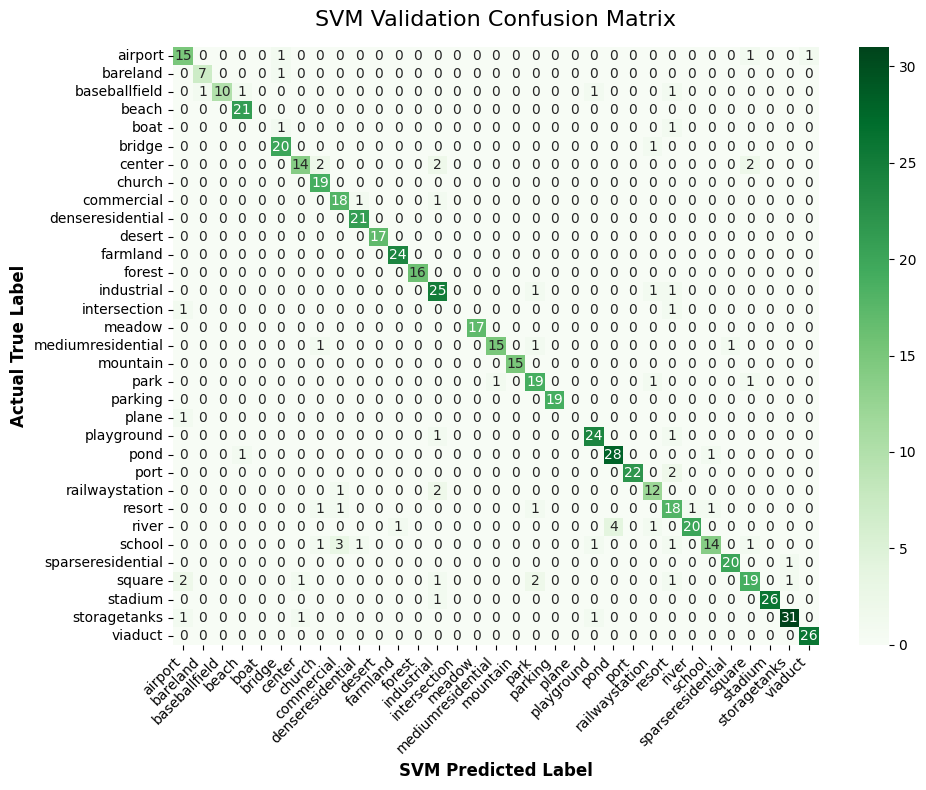

In [ ]:
# ==========================================
# STEP 5: EVALUATE AND GENERATE METRICS
# ==========================================
print("Generating predictions on validation set...")

y_pred = svm_classifier.predict(X_val)

acc = accuracy_score(y_val, y_pred)
balanced_acc = balanced_accuracy_score(y_val, y_pred)
class_report_str = classification_report(y_val, y_pred, target_names=class_names)

print("\n" + "="*40)
print("FINAL SVM TRAINING REPORT")
print("="*40)
print(f"Total SVM Training Time: {svm_train_time_sec:.2f} seconds")
print(f"(Note: SVMs do not use Epochs)")
print("-" * 40)
print(f"Overall Accuracy:    {acc:.4f}")
print(f"Balanced Accuracy:   {balanced_acc:.4f}")
print("-" * 40)
print("Classification Report:")
print(class_report_str)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Gathering data for the SVM confusion matrix...")

# 1. We already have y_val from our extraction step!
y_true = y_val

# 2. Get the model's exact predictions (no argmax needed)
y_pred = svm_classifier.predict(X_val)

# 3. Calculate the raw confusion matrix numbers
cm = confusion_matrix(y_true, y_pred)

# 4. Plot the matrix visually using Seaborn
plt.figure(figsize=(10, 8))

# Create a heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', # Changed to Greens for visual difference
            xticklabels=class_names, yticklabels=class_names)

plt.title('SVM Validation Confusion Matrix', fontsize=16, pad=15)
plt.ylabel('Actual True Label', fontsize=12, fontweight='bold')
plt.xlabel('SVM Predicted Label', fontsize=12, fontweight='bold')

# Rotate the x-axis labels so the disease names don't overlap
plt.xticks(rotation=45, ha='right')

# Adjust layout
plt.tight_layout()
plt.show()

## Test on an image

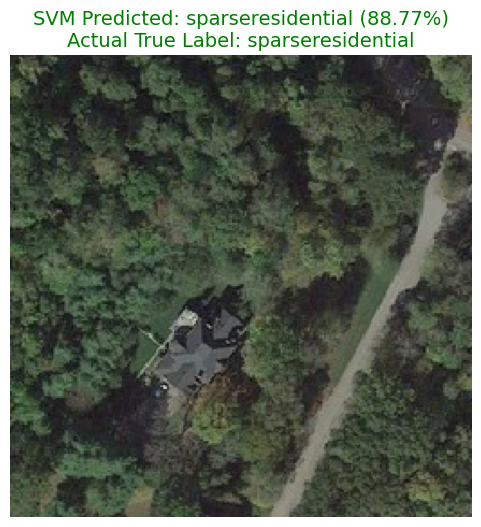

In [ ]:
# ==========================================
# STEP 6: TEST ON A SINGLE IMAGE
# ==========================================

sample_index = 6
sample_example = hf_dataset['validation'][sample_index]

# Extract the raw image and the true INTEGER label
raw_image = sample_example['image']
true_label_index = sample_example['label']

# Convert the integer back to the human-readable string!
true_label_text = class_names[true_label_index]

# 2. Preprocess the image exactly like we did for training
img_tensor = tf.image.resize(raw_image, (224, 224))

# Preprocess image
img_tensor = tf.image.resize(raw_image, IMG_SIZE)
img_tensor = tf.cast(img_tensor, tf.float32)
img_batch = tf.expand_dims(img_tensor, 0)

# Extract feature using ResNet50 FIRST
extracted_feature = feature_extractor.predict(img_batch, verbose=0)

# Pass the feature to the SVM for final prediction
svm_prediction = svm_classifier.predict(extracted_feature)[0]
svm_probabilities = svm_classifier.predict_proba(extracted_feature)[0]

predicted_probability = np.max(svm_probabilities) * 100
predicted_class_name = class_names[svm_prediction]

# Display
plt.figure(figsize=(6, 6))
plt.imshow(raw_image)
plt.title(
    f"SVM Predicted: {predicted_class_name} ({predicted_probability:.2f}%)\n"
    f"Actual True Label: {true_label_text}",
    fontsize=14,
    color='green' if predicted_class_name == true_label_text else 'red'
)
plt.axis('off')
plt.show()

In [ ]:
import joblib
import json

print("Saving models and metadata to disk...")

# 1. Save the trained SVM model
# We use joblib as it is highly optimized for scikit-learn models
svm_filepath = 'svm_model.joblib'
joblib.dump(svm_classifier, svm_filepath)
print(f"✅ SVM saved to: {svm_filepath}")

# NOTE: If you absolutely need a .pkl file for a specific deployment platform,
# you can use this instead:
# import pickle
# with open('svm_model.pkl', 'wb') as f:
#     pickle.dump(svm_classifier, f)

# 2. Save the label mapping (id2label and label2id)
label_mapping = {
    "id2label": {int(i): name for i, name in enumerate(class_names)},
    "label2id": {name: int(i) for i, name in enumerate(class_names)}
}

with open("label_mapping.json", "w") as f:
    json.dump(label_mapping, f, indent=4)
print("✅ Label mapping saved to: label_mapping.json")

# 3. Save the TensorFlow Feature Extractor
# You need this to process raw images before handing them to the SVM!
extractor_filepath = "resnet50_feature_extractor.pt"
feature_extractor.save(extractor_filepath)
print(f"✅ Feature Extractor saved to: {extractor_filepath}")

print("\n🎉 Export complete! You can now download these files from the Colab sidebar.")